<a href="https://colab.research.google.com/github/vaisiria/Deep-learning-lab/blob/main/LSTM_DL_LP6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
LSTM MSE: 7.118383693230902e-05
ESN MSE 2.5677328845235095e-05


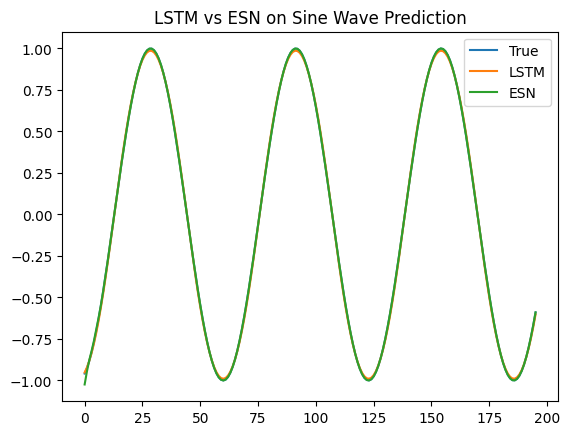

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,Dense
class ESN:
    def __init__(self, n_inputs,n_outputs,n_reservoir=100, spectral_radius=0.95, sparsity=0.1, random_state=None):
        self.n_inputs=n_inputs
        self.n_outputs=n_outputs
        self.n_reservoir=n_reservoir
        self.spectral_radius=spectral_radius
        self.sparsity=sparsity
        self.random_state=np.random.RandomState(random_state)

        self._Win=self.random_state.rand(self.n_reservoir,self.n_inputs) - 0.5
        W=self.random_state.rand(self.n_reservoir,self.n_reservoir) - 0.5

        W[self.random_state.rand(*W.shape)>self.sparsity]=0
        radius=np.max(np.abs(np.linalg.eigvals(W)))
        self._W=W*(self.spectral_radius/radius)

    def update(self,state,input_signal):
        pre_activation=np.dot(self._Win,input_signal)+np.dot(self._W,state)
        return np.tanh(pre_activation)

    def fit(self,X,y):
        states=np.zeros((X.shape[0],self.n_reservoir))
        state=np.zeros(self.n_reservoir)
        for t in range(X.shape[0]):
            state=self.update(state,X[t].flatten())
            states[t]=state
        self._Wout=np.dot(np.linalg.pinv(states),y)
    def predict(self,X):
        predictions=[]
        state=np.zeros(self.n_reservoir)
        for t in range(X.shape[0]):
            state=self.update(state,X[t].flatten())
            y=np.dot(state, self._Wout)
            predictions.append(y)
        return np.array(predictions)


time=np.arange(0,100,0.1)
series=np.sin(time)
def create_dataset(data,window=20):
    X,y=[],[]
    for i in range(len(data)-window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X),np.array(y)
window_size=20
X,y=create_dataset(series,window=window_size)
X=X.reshape((X.shape[0],window_size,1))
split=int(0.8*len(X))
X_train,X_test=X[:split],X[split:]
y_train,y_test=y[:split],y[split:]
lstm=Sequential([
    LSTM(50,input_shape=(window_size,1)),
    Dense(1)
])
lstm.compile(optimizer='adam',loss='mse')
lstm.fit(X_train,y_train,epochs=10,batch_size=32,verbose=0)


lstm_pred=lstm.predict(X_test).flatten()

X_esn=X.reshape(X.shape[0],window_size)
X_train_esn,X_test_esn=X_esn[:split],X_esn[split:]
esn=ESN(n_inputs=window_size,n_outputs=1,n_reservoir=100,random_state=42)
esn.fit(X_train_esn,y_train)
esn_pred=esn.predict(X_test_esn)
print("LSTM MSE:",mean_squared_error(y_test,lstm_pred))
print("ESN MSE",mean_squared_error(y_test,esn_pred))

plt.plot(y_test,label='True')
plt.plot(lstm_pred,label='LSTM')
plt.plot(esn_pred,label='ESN')
plt.legend()
plt.title("LSTM vs ESN on Sine Wave Prediction")
plt.show()